In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest 

In [18]:
df = pd.read_csv("..\preprocessing\data\cleaned_laptop_data.csv") 
df

,type_name,user_profile,budget_class,upgrade_first,gain_class,price,recommended_upgrade_cost_est,inches,weight_kg,opsys,...,gpu_urgency_score,performance_score,ram_gap_ratio,storage_gap_ratio,gpu_gap_ratio,upgrade_pressure,total_urgency,price_per_performance,storage_capacity_score,storage_speed_score
0,Ultrabook,student,low,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
1,Ultrabook,student,medium,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
2,Ultrabook,student,high,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
3,Ultrabook,office,low,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
4,Ultrabook,office,medium,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.000,12.150286,0.000000,0.498054,0.000000,0.124514,0.113667,5427.918441,128,128.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19540,Notebook,designer,medium,RAM,High,19660.32,45.84,15.6,2.20,Windows 10,...,0.733,2.985060,0.705882,0.499500,0.555556,0.594156,0.880000,4933.506157,500,225.0
19541,Notebook,designer,high,RAM,High,19660.32,45.84,15.6,2.20,Windows 10,...,0.919,2.985060,0.705882,0.499500,0.555556,0.594156,0.942000,4933.506157,500,225.0
19542,Notebook,gamer,low,RAM,High,19660.32,45.84,15.6,2.20,Windows 10,...,0.446,2.985060,0.705882,0.023392,0.636364,0.507452,0.701333,4933.506157,500,225.0
19543,Notebook,gamer,medium,RAM,High,19660.32,45.84,15.6,2.20,Windows 10,...,0.646,2.985060,0.705882,0.023392,0.636364,0.507452,0.768000,4933.506157,500,225.0


In [19]:
features = [
    "price",
    "price_per_performance",
    "performance_score",
    "cpu_score",
    "gpu_score",
    "ram_gb",
    "recommended_upgrade_cost_est",
    "total_urgency"
]

X = df[features].copy() 

In [21]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
iso_forest.fit(X) 

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [22]:
df["anomaly_score"] = iso_forest.decision_function(X)
df["anomaly_flag"] = iso_forest.predict(X) 

In [23]:
def label_anomaly(score):
    if score > 0.1:
        return "Normal"
    elif score > 0:
        return "Slightly Unusual"
    elif score > -0.1:
        return "Needs Attention"
    else:
        return "High-Risk Mismatch"

df["anomaly_label"] = df["anomaly_score"].apply(label_anomaly) 

In [24]:
def explain_anomaly(row):
    reasons = []

    if row["price_per_performance"] > df["price_per_performance"].quantile(0.9):
        reasons.append("Poor price-to-performance ratio")

    if row["performance_score"] < df["performance_score"].quantile(0.2):
        reasons.append("Low overall performance")

    if row["price"] > df["price"].quantile(0.9) and row["gpu_score"] < df["gpu_score"].quantile(0.3):
        reasons.append("High price but weak GPU")

    if row["recommended_upgrade_cost_est"] > df["recommended_upgrade_cost_est"].quantile(0.9):
        reasons.append("Very high upgrade cost")

    if row["ram_gb"] < df["ram_gb"].quantile(0.2):
        reasons.append("Low RAM compared to typical laptops")

    if row["cpu_score"] < df["cpu_score"].quantile(0.2):
        reasons.append("Low CPU performance")

    if not reasons:
        return "No strong anomaly reason detected"

    return ", ".join(reasons)

In [25]:
df["anomaly_explanation"] = df.apply(explain_anomaly, axis=1)

df[["anomaly_score", "anomaly_label", "anomaly_explanation"]].head() 

,anomaly_score,anomaly_label,anomaly_explanation
0,0.135992,Normal,No strong anomaly reason detected
1,0.135992,Normal,No strong anomaly reason detected
2,0.135992,Normal,No strong anomaly reason detected
3,0.135992,Normal,No strong anomaly reason detected
4,0.135992,Normal,No strong anomaly reason detected


In [26]:
df[df["anomaly_flag"] == -1].head(10) 

,type_name,user_profile,budget_class,upgrade_first,gain_class,price,recommended_upgrade_cost_est,inches,weight_kg,opsys,...,gpu_gap_ratio,upgrade_pressure,total_urgency,price_per_performance,storage_capacity_score,storage_speed_score,anomaly_score,anomaly_flag,anomaly_label,anomaly_explanation
55,Ultrabook,designer,medium,GPU,Low,135195.34,329.99,15.4,1.83,macOS,...,0.333333,0.255211,0.201667,7049.575257,512,512.0,-0.013374,-1,Needs Attention,Poor price-to-performance ratio
56,Ultrabook,designer,high,GPU,Low,135195.34,329.99,15.4,1.83,macOS,...,0.333333,0.255211,0.239000,7049.575257,512,512.0,-0.008559,-1,Needs Attention,Poor price-to-performance ratio
58,Ultrabook,gamer,medium,GPU,Low,135195.34,498.00,15.4,1.83,macOS,...,0.454545,0.181818,0.118000,7049.575257,512,512.0,-0.050578,-1,Needs Attention,"Poor price-to-performance ratio, Very high upg..."
59,Ultrabook,gamer,high,GPU,Medium,135195.34,498.00,15.4,1.83,macOS,...,0.454545,0.181818,0.235333,7049.575257,512,512.0,-0.045265,-1,Needs Attention,"Poor price-to-performance ratio, Very high upg..."
134,Ultrabook,gamer,high,GPU,Medium,79653.60,498.00,14.0,1.30,Windows 10,...,0.409091,0.163636,0.211667,4398.036964,512,512.0,-0.018775,-1,Needs Attention,Very high upgrade cost
164,Notebook,gamer,high,GPU,High,20986.99,498.00,15.6,1.86,No OS,...,0.636364,0.507452,0.932000,1944.015018,500,225.0,-0.000347,-1,Needs Attention,Very high upgrade cost
179,Notebook,gamer,high,GPU,High,18381.07,498.00,15.6,1.86,No OS,...,0.636364,0.507452,0.932000,2296.601777,500,225.0,-0.007288,-1,Needs Attention,"Low overall performance, Very high upgrade cost"
220,Ultrabook,designer,medium,GPU,Medium,67260.67,329.99,12.0,0.92,macOS,...,0.555556,0.572742,0.602333,9637.267423,256,256.0,-0.002078,-1,Needs Attention,"Poor price-to-performance ratio, Low overall p..."
221,Ultrabook,designer,high,GPU,High,67260.67,329.99,12.0,0.92,macOS,...,0.555556,0.572742,0.664333,9637.267423,256,256.0,-0.003536,-1,Needs Attention,"Poor price-to-performance ratio, Low overall p..."
223,Ultrabook,gamer,medium,GPU,Medium,67260.67,498.00,12.0,0.92,macOS,...,0.636364,0.544008,0.530667,9637.267423,256,256.0,-0.028287,-1,Needs Attention,"Poor price-to-performance ratio, Low overall p..."


In [27]:
df["anomaly_label"].value_counts() 

anomaly_label
Normal                11471
Slightly Unusual       7096
Needs Attention         895
High-Risk Mismatch       83
Name: count, dtype: int64

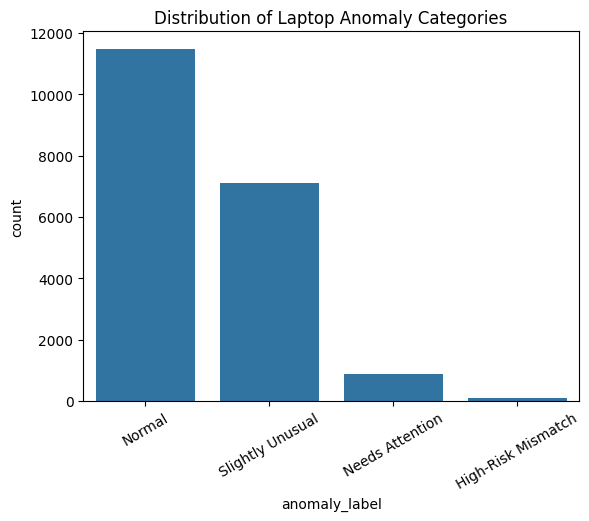

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(data=df, x="anomaly_label")
plt.title("Distribution of Laptop Anomaly Categories")
plt.xticks(rotation=30)
plt.show() 

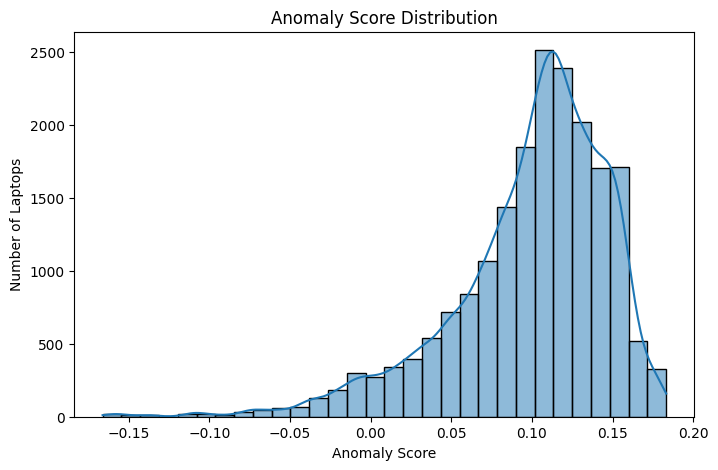

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["anomaly_score"], bins=30, kde=True)
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Laptops")
plt.show() 

In [32]:


import joblib

joblib.dump(iso_forest, "isolation_forest_model.pkl")

print("Anomaly model saved successfully.")

Anomaly model saved successfully.
